# how we use pdf

In [1]:
import seaborn as sns
df = sns.load_dataset('iris')
df.head()

In [3]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

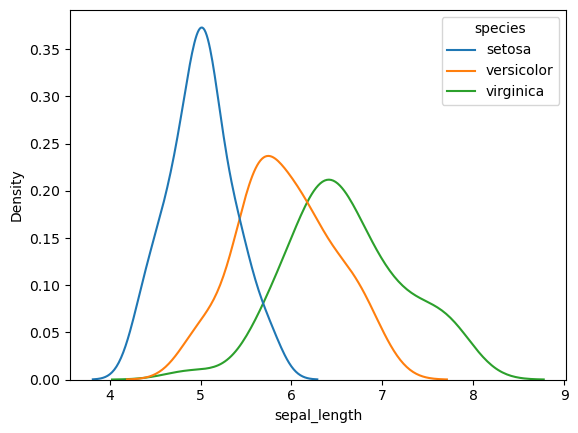

In [7]:
# drawing pdf using kde
sns.kdeplot(data=df, x='sepal_length', hue='species')

<Axes: xlabel='sepal_width', ylabel='Density'>

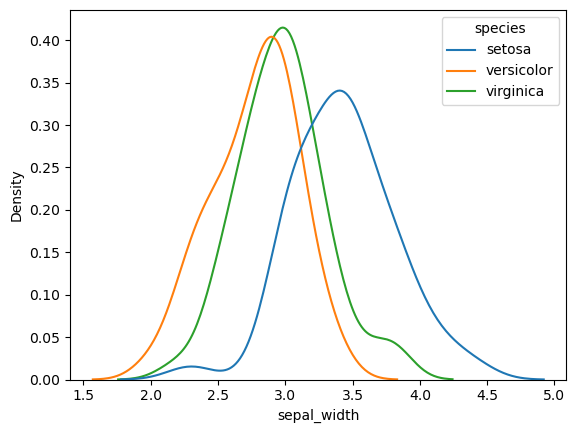

In [8]:
sns.kdeplot(data=df, x='sepal_width', hue='species')

<Axes: xlabel='petal_length', ylabel='Density'>

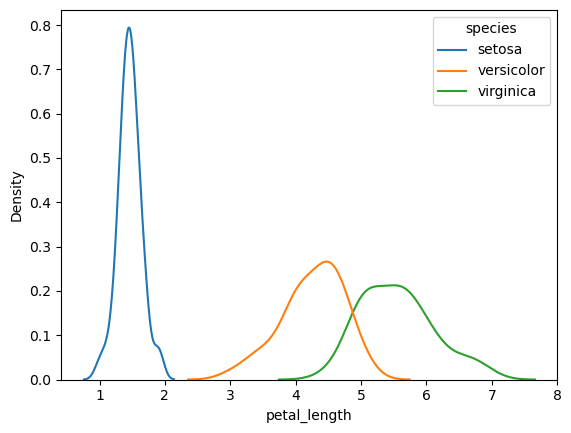

In [11]:
sns.kdeplot(data=df, x='petal_length', hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

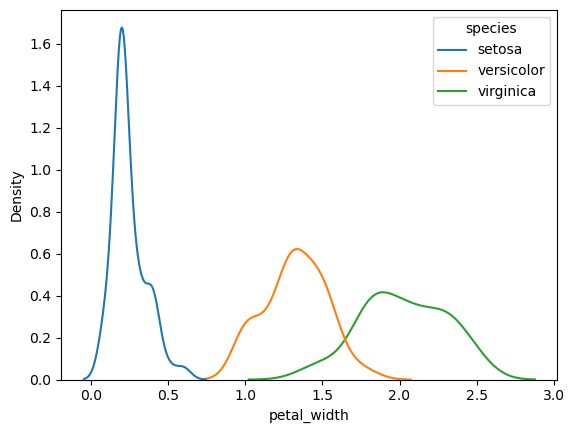

In [12]:
sns.kdeplot(data=df, x='petal_width', hue='species')

In [41]:
import numpy as np

rng = np.random.default_rng()

a = rng.normal(4, 14, size=(100))

In [42]:
mean = a.mean()
std = a.std()
print(mean)
print(std)

2.966901474463552
13.575977521474567


In [43]:
# we standerdize
b = a - mean
b = b/std

In [44]:
b.mean()

np.float64(-2.1094237467877975e-17)

In [45]:
import numpy as np

rng = np.random.default_rng()

# 1. Generate original data
a = rng.normal(4, 14, size=(1000)) # Increased size for better statistical accuracy

# 2. Calculate current parameters
mean_a = a.mean()
std_a = a.std()

# 3. Standardize (The Formula: (x - mu) / sigma)
b = (a - mean_a) / std_a

# 4. Verify the results for 'b'
print(f"Standardized Mean: {b.mean():.4f}")  # Should be ~0
print(f"Standardized Std:  {b.std():.4f}")   # Should be ~1

Standardized Mean: 0.0000
Standardized Std:  1.0000


<Axes: ylabel='Density'>

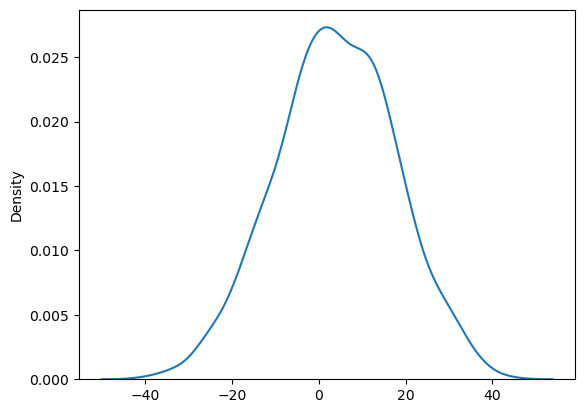

In [47]:
import seaborn as sns

sns.kdeplot(a)

<Axes: ylabel='Density'>

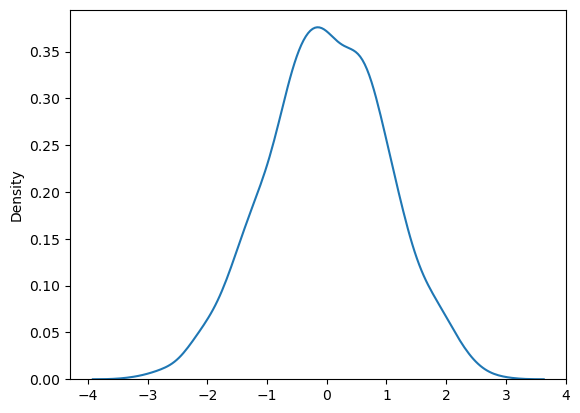

In [48]:
sns.kdeplot(b)

In [14]:
4

4

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns

rng = np.random.default_rng()

# 1. Generate original data
a = rng.normal(4, 14, size=(1000)) # Increased size for better statistical accuracy

skewed_data = np.exp(a / 15)

# 2. Calculate current parameters
print(skewed_data.mean())
print( skewed_data.std())

2.0096904408765526
2.509799566064462


In [25]:
df = pd.Series(skewed_data)
print(df.skew())

7.643271180330412


<Axes: ylabel='Density'>

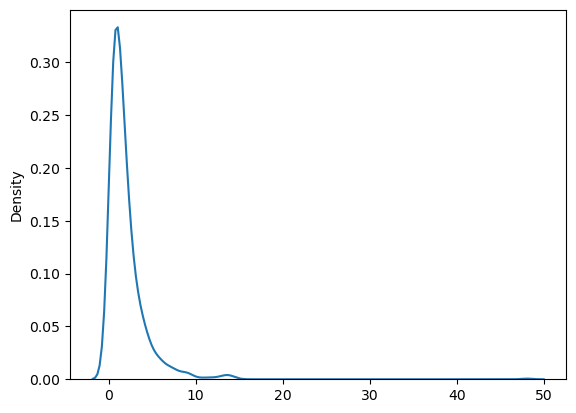

In [26]:
sns.kdeplot(skewed_data)

In [42]:
4

4

In [39]:
# skewd_data is normally distributed skewd_data
# so we first found the points mean + 3* std deviation  and mean - 3* std deviation
# by this we can get 99.7 percentage of datapoints
mean_ = skewed_data.mean()
std_ = skewed_data.std()

left_point = mean_ - (3 * std_)
right_point = mean_ + ( 3* std_)

print(left_point)
print(right_point)

-5.519708257316834
9.539089139069938


before outlier removel ::  1000


<Axes: ylabel='Density'>

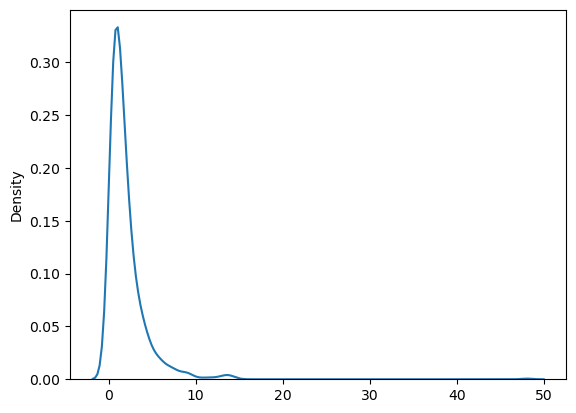

In [40]:
print("before outlier removel :: ",len(skewed_data))
sns.kdeplot(skewed_data)

In [44]:
4

4

before outlier removel ::  986


<Axes: ylabel='Density'>

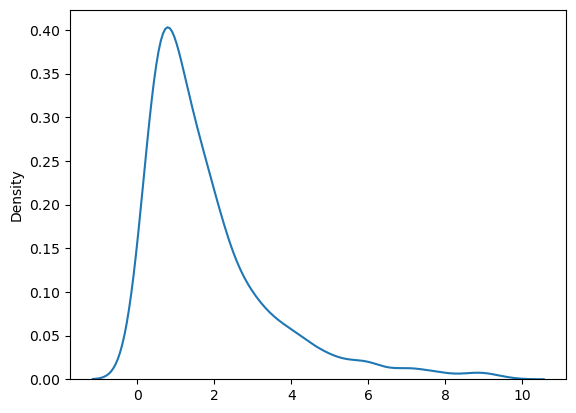

In [41]:
filter_dist = skewed_data[ (skewed_data >= left_point) & (skewed_data <= right_point) ]
print("before outlier removel :: ",len(filter_dist))
sns.kdeplot(filter_dist)

In [49]:
import seaborn as sns
import numpy as np
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

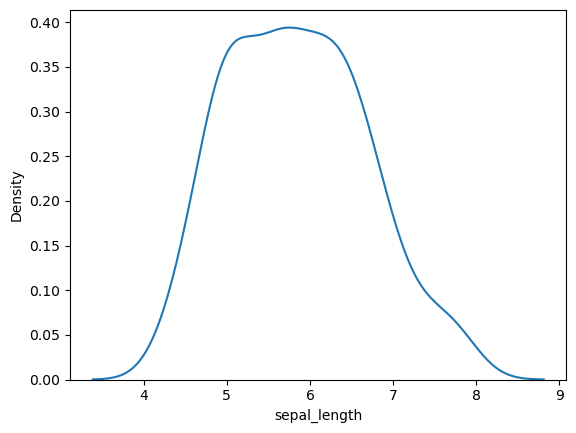

In [50]:
sns.kdeplot(df['sepal_length'])

In [56]:
temp = sorted(df['sepal_length'].to_list())

y_quant = []
for i in range(1,101):
    y_quant.append(np.percentile(temp, i))


# taking the therotical normal distribution 
# it is already sorted
samples = np.random.normal(loc=0, scale=1, 1000)

x_quant = []
for i in range(1,101):
    y_quant.append(np.percentile(samples, i))

sns.scatterplot(x=x_quant, y=y_quant)

SyntaxError: positional argument follows keyword argument (1277102405.py, line 10)

<Axes: >

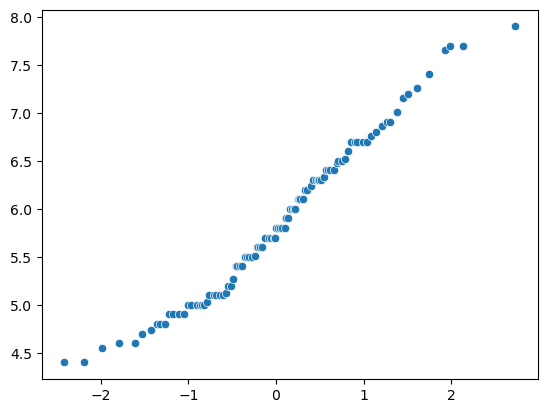

In [53]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare and sort your data
temp = sorted(df['sepal_length'].to_list())

y_quant = []
for i in range(1, 101):
    y_quant.append(np.percentile(temp, i)) # Fix: added missing ')'

# 2. Generate theoretical normal distribution 
samples = np.random.normal(loc=0, scale=1, size=1000) # Fix: defined size

x_quant = []
for i in range(1, 101):
    # Fix: Append to x_quant, NOT y_quant
    x_quant.append(np.percentile(samples, i)) 

# 3. Plot
sns.scatterplot(x=x_quant, y=y_quant)

In [54]:
4

4

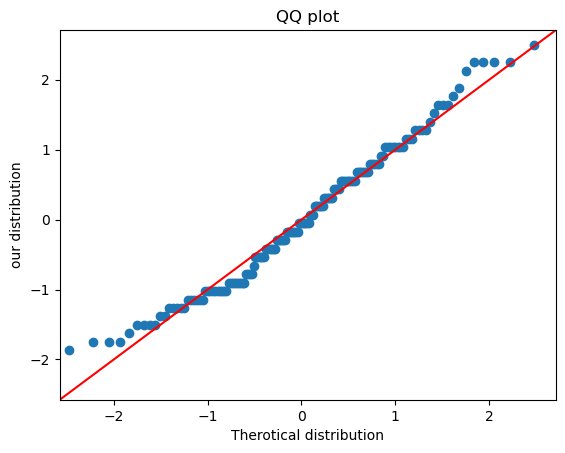

In [57]:
import statsmodels.api as sm
import matplotlib.pyplot as plt


# create a QQ plot of the two sets of data
fig = sm.qqplot(df['sepal_length'], line='45',fit=True )

# add title
plt.title('QQ plot')
plt.xlabel('Therotical distribution')
plt.ylabel('our distribution')

# show the plot
plt.show()

In [58]:
4

4

(array([118.,  98.,  87.,  92., 109., 104.,  90.,  92., 105., 105.]),
 array([5.90301187e-04, 1.00281916e-01, 1.99973532e-01, 2.99665147e-01,
        3.99356762e-01, 4.99048377e-01, 5.98739992e-01, 6.98431607e-01,
        7.98123223e-01, 8.97814838e-01, 9.97506453e-01]),
 <BarContainer object of 10 artists>)

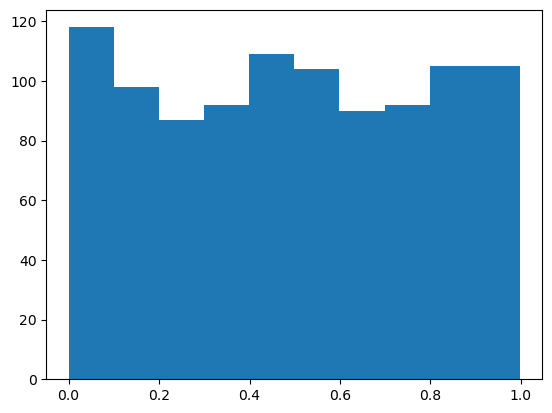

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm


# generate random uniform data
x = np.random.uniform(low=0, high=1, size=1000)

plt.hist(x)

In [9]:
params

(0.0005903011868713115, 0.9969161518661723)

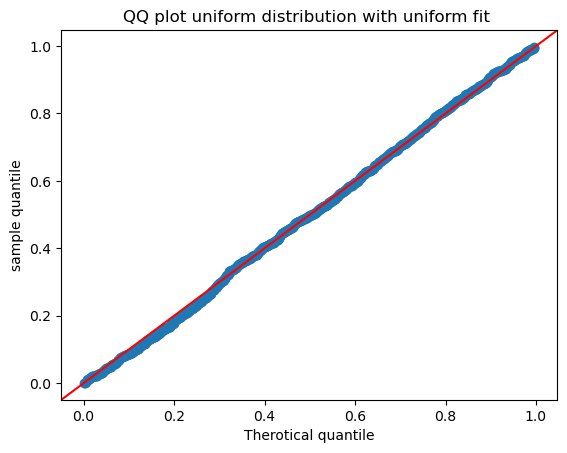

In [6]:
# fit uniform distribution to data
params = stats.uniform.fit(x)
dist = stats.uniform(loc=params[0], scale=params[1])

# create a QQ plot of the two sets of data
fig = sm.qqplot(x, dist=dist, line='45')

# add title
plt.title('QQ plot uniform distribution with uniform fit ')
plt.xlabel('Therotical quantile')
plt.ylabel('sample quantile')

# show the plot
plt.show()


In [8]:
4

4